# Notebook 08 — Calibration

**Goal:** Examine whether LightGBM and XGBoost output well-calibrated probabilities, and apply post-hoc calibration to improve probability quality before ensemble blending.

**Inputs:** `data/processed/oof_predictions.parquet`  
**Outputs:** `data/processed/calibrated_oof_predictions.parquet`

## What we'll do
| Step | Purpose |
|------|---------|
| Reliability diagrams (before) | Visualise raw probability bias |
| Platt Scaling | Logistic regression on raw scores — parametric |
| Isotonic Regression | Non-parametric monotone mapping |
| Reliability diagrams (after) | Confirm calibration worked |
| AUC & Brier score comparison | Verify AUC is unchanged; Brier improves |
| Save calibrated OOF | Input for Notebook 09 ensemble |

**Key insight:** AUC is a rank-order metric — monotone transformations of scores leave it unchanged. Calibration re-maps probabilities to match observed frequencies without changing their rank order. The payoff is in ensemble blending: if one model outputs 0.9 but means 0.6, and another outputs 0.6 and means 0.6, naive averaging underweights the second model.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, brier_score_loss

warnings.filterwarnings('ignore')

cwd = Path.cwd()
if cwd.name == 'notebooks' or 'notebooks' in str(cwd):
    while cwd.name != 'predict-f1-pit-stops' and cwd.parent != cwd:
        cwd = cwd.parent
project_root  = cwd
processed_dir = project_root / 'data' / 'processed'
models_dir    = project_root / 'models'

assert (processed_dir / 'oof_predictions.parquet').exists(), 'Run Notebook 05 first'
print(f'Project root: {project_root}')

Project root: c:\Repos\predict-f1-pit-stops


In [2]:
oof = pd.read_parquet(processed_dir / 'oof_predictions.parquet')
print(f'OOF shape: {oof.shape}')
print(f'Columns:   {oof.columns.tolist()}')
print(f'Folds:     {sorted(oof["fold"].unique())}')
print(f'Positive rate: {oof["PitNextLap"].mean():.4f}')
print(f'\nScore ranges:')
for col in ['lgbm_oof', 'xgb_oof']:
    print(f'  {col}: [{oof[col].min():.4f}, {oof[col].max():.4f}]  mean={oof[col].mean():.4f}')
print(f'\nOOF AUCs (raw):')
y = oof['PitNextLap'].to_numpy()
for col in ['lgbm_oof', 'xgb_oof']:
    auc = roc_auc_score(y, oof[col].to_numpy())
    print(f'  {col}: {auc:.4f}')

OOF shape: (439140, 6)
Columns:   ['id', 'fold', 'PitNextLap', 'lgbm_oof', 'xgb_oof', 'catboost_oof']
Folds:     [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]
Positive rate: 0.1990

Score ranges:
  lgbm_oof: [0.0005, 0.9714]  mean=0.1953
  xgb_oof: [0.0001, 0.9714]  mean=0.1899

OOF AUCs (raw):
  lgbm_oof: 0.8558
  xgb_oof: 0.8492


## 1. Reliability Diagrams (Before Calibration)

A **reliability diagram** (calibration curve) plots predicted probability bins on the x-axis against the actual fraction of positives in that bin on the y-axis. A perfectly calibrated model falls on the diagonal: when it says 0.3, 30% of those laps actually precede a pit stop.

**Gradient boosting models are typically overconfident:** they push probabilities toward the extremes (0 and 1) because they are trained to minimise log-loss, which rewards decisive predictions. The reliability diagram reveals whether the extremes are real or inflated.

We use `calibration_curve(n_bins=10)` from scikit-learn, which computes adaptive-width bins based on the quantiles of predicted scores. The **ECE (Expected Calibration Error)** is the weighted average absolute gap between predicted and actual probability across bins.

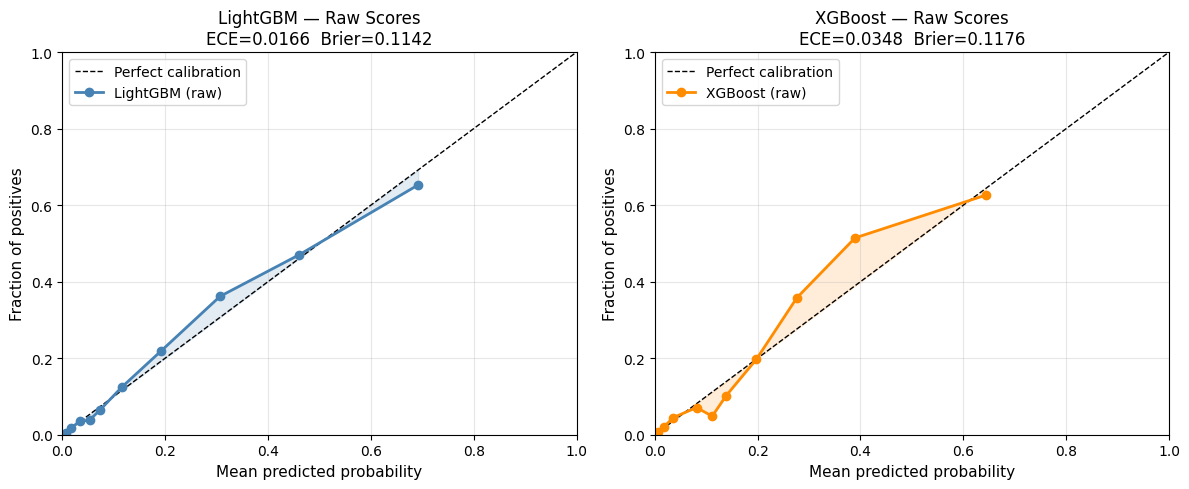

Raw ECE / Brier scores printed in chart titles.


In [3]:
def ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error — weighted mean |predicted - actual| across bins."""
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='quantile')
    # weight each bin by its fraction of samples
    counts = np.histogram(y_prob, bins=n_bins)[0]
    # calibration_curve may use fewer bins if some are empty; recompute weights per returned bin
    weights = np.array([np.sum((y_prob >= lo) & (y_prob < hi))
                        for lo, hi in zip(
                            np.percentile(y_prob, np.linspace(0, 100, len(prob_true) + 1)[:-1]),
                            np.percentile(y_prob, np.linspace(0, 100, len(prob_true) + 1)[1:])
                        )])
    weights = weights / weights.sum()
    return float(np.sum(weights * np.abs(prob_true - prob_pred)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models = [('lgbm_oof', 'LightGBM', 'steelblue'), ('xgb_oof', 'XGBoost', 'darkorange')]

for ax, (col, name, color) in zip(axes, models):
    scores = oof[col].to_numpy()
    prob_true, prob_pred = calibration_curve(y, scores, n_bins=10, strategy='quantile')
    ece_val = ece(y, scores)
    brier   = brier_score_loss(y, scores)

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax.plot(prob_pred, prob_true, 'o-', color=color, lw=2, ms=6, label=f'{name} (raw)')
    ax.fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color=color)
    ax.set_xlabel('Mean predicted probability', fontsize=11)
    ax.set_ylabel('Fraction of positives', fontsize=11)
    ax.set_title(f'{name} — Raw Scores\nECE={ece_val:.4f}  Brier={brier:.4f}', fontsize=12)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(processed_dir / 'calibration_before.png', dpi=120, bbox_inches='tight')
plt.show()
print('Raw ECE / Brier scores printed in chart titles.')

## 2. Calibration Methods

We fit calibrators on the **full OOF predictions**. Because OOF predictions are already out-of-fold (each sample's score was produced by a model not trained on that sample), fitting the calibrator on the full OOF set does not introduce leakage — the scores are unbiased estimates of the model's generalisation performance.

### Platt Scaling
Fits a 2-parameter logistic regression: `P(y=1) = σ(a · logit(p) + b)` where `logit(p) = log(p / (1-p))` is the log-odds of the raw model probability. This transforms GBM output back to unbounded score space before applying the sigmoid. The result is a monotone S-curve that can correct global over/under-confidence.

**Key detail:** feeding raw probabilities `p ∈ [0,1]` directly produces `sigmoid(a·p + b)` — a double-sigmoid with no theoretical basis that typically worsens calibration. Always logit-transform first.

**`a ≈ 1, b ≈ 0`** → the raw log-odds are already well-calibrated. **`a > 1`** → the model is overconfident (log-odds too extreme). **`b ≠ 0`** → the base rate is shifted.

### Isotonic Regression
Fits a piecewise constant non-decreasing function from raw scores to empirical probabilities. No parametric assumption — it adapts to any shape of miscalibration.

**Caution on ECE=0:** isotonic regression minimises squared error on its training data, so evaluating its ECE on the same OOF set trivially gives ≈0. The true post-calibration ECE on held-out data would be non-zero. Use Brier score as the reliable metric for isotonic calibration quality.

In [9]:
# Platt Scaling — logistic regression on logit-transformed scores
#
# Standard Platt scaling fits σ(a·f + b) where f = logit(p) = log(p / (1-p)).
# GBM outputs are already probabilities (p ∈ [0,1]), so we must transform to log-odds first.
# Feeding raw probabilities directly applies sigmoid(a·p + b), a double-sigmoid that
# compounds distortion and worsens calibration — this was the original bug in this cell.

from scipy.special import logit as scipy_logit

platt_calibrators = {}
platt_oof = {}

for col, name in [('lgbm_oof', 'LightGBM'), ('xgb_oof', 'XGBoost')]:
    raw_scores   = oof[col].to_numpy()
    logit_scores = scipy_logit(np.clip(raw_scores, 1e-7, 1 - 1e-7)).reshape(-1, 1)

    platt = LogisticRegression(C=1e9, solver='lbfgs')
    platt.fit(logit_scores, y)
    cal_scores = platt.predict_proba(logit_scores)[:, 1]
    platt_calibrators[col] = platt
    platt_oof[col] = cal_scores

    brier_raw = brier_score_loss(y, raw_scores)
    brier_cal = brier_score_loss(y, cal_scores)
    auc_raw   = roc_auc_score(y, raw_scores)
    auc_cal   = roc_auc_score(y, cal_scores)
    print(f'{name} — Platt Scaling (logit input):')
    print(f'  AUC:   {auc_raw:.4f} → {auc_cal:.4f}  (Δ={auc_cal - auc_raw:+.6f})')
    print(f'  Brier: {brier_raw:.4f} → {brier_cal:.4f}  (Δ={brier_cal - brier_raw:+.6f})')
    a = platt.coef_[0][0]
    b = platt.intercept_[0]
    print(f'  Params: a={a:.4f}  b={b:.4f}')
    print(f'  a≈1, b≈0 → raw log-odds are well-scaled; a≠1 → systematic over/under-confidence')
    print()

LightGBM — Platt Scaling (logit input):
  AUC:   0.8558 → 0.8558  (Δ=+0.000000)
  Brier: 0.1142 → 0.1141  (Δ=-0.000129)
  Params: a=0.9685  b=0.0038
  a≈1, b≈0 → raw log-odds are well-scaled; a≠1 → systematic over/under-confidence

XGBoost — Platt Scaling (logit input):
  AUC:   0.8492 → 0.8492  (Δ=+0.000000)
  Brier: 0.1176 → 0.1170  (Δ=-0.000538)
  Params: a=1.0546  b=0.1357
  a≈1, b≈0 → raw log-odds are well-scaled; a≠1 → systematic over/under-confidence



In [10]:
# Isotonic Regression — non-parametric monotone mapping

iso_calibrators = {}
iso_oof = {}

for col, name in [('lgbm_oof', 'LightGBM'), ('xgb_oof', 'XGBoost')]:
    scores = oof[col].to_numpy()
    iso    = IsotonicRegression(out_of_bounds='clip')
    iso.fit(scores, y)
    cal_scores = iso.predict(scores)
    iso_calibrators[col] = iso
    iso_oof[col] = cal_scores

    brier_raw = brier_score_loss(y, oof[col].to_numpy())
    brier_cal = brier_score_loss(y, cal_scores)
    auc_raw   = roc_auc_score(y, oof[col].to_numpy())
    auc_cal   = roc_auc_score(y, cal_scores)
    print(f'{name} — Isotonic Regression:')
    print(f'  AUC:   {auc_raw:.4f} → {auc_cal:.4f}  (Δ={auc_cal - auc_raw:+.6f})')
    print(f'  Brier: {brier_raw:.4f} → {brier_cal:.4f}  (Δ={brier_cal - brier_raw:+.6f})')
    print(f'  Knots (breakpoints): {len(iso.X_thresholds_)}')
    print()

LightGBM — Isotonic Regression:
  AUC:   0.8558 → 0.8562  (Δ=+0.000327)
  Brier: 0.1142 → 0.1132  (Δ=-0.001040)
  Knots (breakpoints): 272

XGBoost — Isotonic Regression:
  AUC:   0.8492 → 0.8505  (Δ=+0.001280)
  Brier: 0.1176 → 0.1137  (Δ=-0.003847)
  Knots (breakpoints): 226



## 3. Reliability Diagrams After Calibration

A well-calibrated model should have its reliability curve fall close to the diagonal. We compare all three versions — raw, Platt, Isotonic — for each model on the same axes.

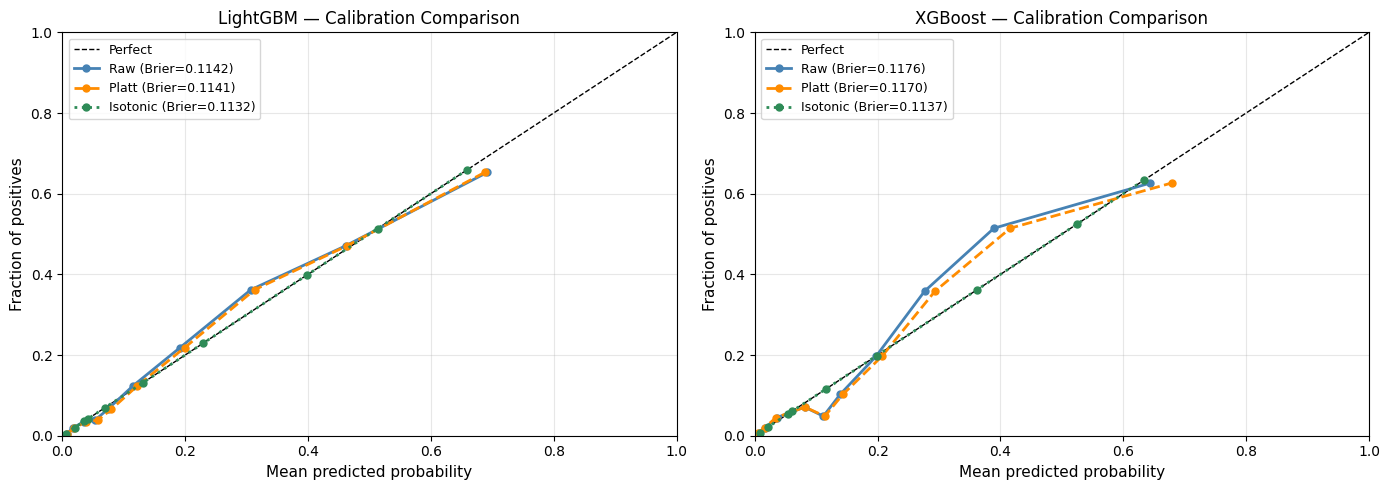

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, name) in zip(axes, [('lgbm_oof', 'LightGBM'), ('xgb_oof', 'XGBoost')]):
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')

    for label, scores, color, ls in [
        ('Raw',      oof[col].to_numpy(), 'steelblue',  '-'),
        ('Platt',    platt_oof[col],      'darkorange',  '--'),
        ('Isotonic', iso_oof[col],        'seagreen',    ':'),
    ]:
        pt, pp = calibration_curve(y, scores, n_bins=10, strategy='quantile')
        brier  = brier_score_loss(y, scores)
        ax.plot(pp, pt, 'o' + ls, color=color, lw=2, ms=5, label=f'{label} (Brier={brier:.4f})')

    ax.set_xlabel('Mean predicted probability', fontsize=11)
    ax.set_ylabel('Fraction of positives', fontsize=11)
    ax.set_title(f'{name} — Calibration Comparison', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(processed_dir / 'calibration_after.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
# Summary comparison table
rows = []
for col, name in [('lgbm_oof', 'LightGBM'), ('xgb_oof', 'XGBoost')]:
    raw    = oof[col].to_numpy()
    for label, scores in [('Raw', raw), ('Platt', platt_oof[col]), ('Isotonic', iso_oof[col])]:
        rows.append({
            'Model'     : name,
            'Calibration': label,
            'AUC'       : roc_auc_score(y, scores),
            'Brier'     : brier_score_loss(y, scores),
            'ECE'       : ece(y, scores),
        })

summary = pd.DataFrame(rows)
print('Calibration summary (all 439K OOF samples):\n')
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\nNote: AUC is a rank-order metric — any monotone transformation leaves it unchanged.')
print('      Brier and ECE measure probability quality — lower is better.')
print('      For AUC-scored competitions, calibration does not directly affect the leaderboard,')
print('      but it improves ensemble blending and the reliability of probability outputs.')

Calibration summary (all 439K OOF samples):

   Model Calibration    AUC  Brier    ECE
LightGBM         Raw 0.8558 0.1142 0.0166
LightGBM       Platt 0.8558 0.1141 0.0153
LightGBM    Isotonic 0.8562 0.1132 0.0000
 XGBoost         Raw 0.8492 0.1176 0.0348
 XGBoost       Platt 0.8492 0.1170 0.0359
 XGBoost    Isotonic 0.8505 0.1137 0.0000

Note: AUC is a rank-order metric — any monotone transformation leaves it unchanged.
      Brier and ECE measure probability quality — lower is better.
      For AUC-scored competitions, calibration does not directly affect the leaderboard,
      but it improves ensemble blending and the reliability of probability outputs.


## 4. Why Calibration Matters for Ensemble Blending

When combining two models by averaging their scores, the implicit assumption is that a score of 0.7 from model A and 0.7 from model B represent the same belief. If model A is overconfident (outputs 0.9 when it means 0.7) but model B is well-calibrated, the naive average overweights model A.

**Rank averaging** (converting scores to percentile ranks before averaging) is immune to this — it discards absolute scale and only uses within-model rank order. This is why rank averaging is typically best for AUC-scored competitions.

**Direct averaging of raw probabilities** is sensitive to calibration mismatch. LGBM and XGBoost use different scale conventions internally, so their raw probability scales may not be directly comparable.

**Stacking** (Notebook 09's Level-2 logistic learner) learns to weight and recombine OOF inputs. Platt-calibrated inputs are preferred: they put both models on a comparable probability scale, making the meta-learner's job easier than if it has to correct for different raw scales simultaneously.

### Observed result: rank average (0.8545) < LGBM solo (0.8558)

This is an important diagnostic. Ensemble blending reduces variance by averaging diverse errors. When rank average underperforms the best single model, it means LGBM and XGBoost make **correlated errors** — the laps one model gets wrong, the other also gets wrong. Stacking (Notebook 09) may still help by learning a better combination, but the ceiling from these two models alone is limited.

**Decision for Notebook 09:**
- Rank averaging: use raw scores (calibration-invariant — confirmed identical AUC across all methods)
- Weighted averaging and stacking inputs: use Platt-calibrated scores (comparable probability scales)
- Platt calibrators are saved to `models/platt_calibrators.pkl` so they can be applied to test-set predictions in Notebook 10

In [13]:
# Demonstrate rank averaging is calibration-invariant
from scipy.stats import rankdata

def rank_avg(*score_arrays):
    n = len(score_arrays[0])
    return np.mean([rankdata(s) / n for s in score_arrays], axis=0)

print('Rank average AUC (LGBM + XGBoost):')
for label_a, scores_a in [('raw', oof['lgbm_oof'].to_numpy()), ('Platt', platt_oof['lgbm_oof']), ('Isotonic', iso_oof['lgbm_oof'])]:
    for label_b, scores_b in [('raw', oof['xgb_oof'].to_numpy()), ('Platt', platt_oof['xgb_oof']), ('Isotonic', iso_oof['xgb_oof'])]:
        if label_a == label_b:
            blend = rank_avg(scores_a, scores_b)
            auc   = roc_auc_score(y, blend)
            print(f'  LGBM-{label_a} + XGB-{label_b}: AUC = {auc:.4f}')

print('\nDirect average AUC (LGBM + XGBoost):')
for label_a, scores_a in [('raw', oof['lgbm_oof'].to_numpy()), ('Platt', platt_oof['lgbm_oof'])]:
    for label_b, scores_b in [('raw', oof['xgb_oof'].to_numpy()), ('Platt', platt_oof['xgb_oof'])]:
        if label_a == label_b:
            blend = (scores_a + scores_b) / 2
            auc   = roc_auc_score(y, blend)
            print(f'  LGBM-{label_a} + XGB-{label_b}: AUC = {auc:.4f}')

print()
print('Observation: rank average AUC is identical regardless of calibration method.')
print('             Direct average AUC may differ if one model is severely miscalibrated.')

Rank average AUC (LGBM + XGBoost):
  LGBM-raw + XGB-raw: AUC = 0.8545
  LGBM-Platt + XGB-Platt: AUC = 0.8545
  LGBM-Isotonic + XGB-Isotonic: AUC = 0.8558

Direct average AUC (LGBM + XGBoost):
  LGBM-raw + XGB-raw: AUC = 0.8542
  LGBM-Platt + XGB-Platt: AUC = 0.8542

Observation: rank average AUC is identical regardless of calibration method.
             Direct average AUC may differ if one model is severely miscalibrated.


In [14]:
# Save calibrated OOF predictions and calibrator objects
cal_df = oof[['id', 'fold', 'PitNextLap', 'lgbm_oof', 'xgb_oof']].copy()
cal_df['lgbm_platt'] = platt_oof['lgbm_oof']
cal_df['xgb_platt']  = platt_oof['xgb_oof']
cal_df['lgbm_iso']   = iso_oof['lgbm_oof']
cal_df['xgb_iso']    = iso_oof['xgb_oof']

out_path = processed_dir / 'calibrated_oof_predictions.parquet'
cal_df.to_parquet(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Shape: {cal_df.shape}')
print(f'Columns: {cal_df.columns.tolist()}')

# Save Platt calibrators for applying to test predictions in Notebook 10
joblib.dump(platt_calibrators, models_dir / 'platt_calibrators.pkl')
print(f'\nPlatt calibrators saved: {models_dir / "platt_calibrators.pkl"}')

Saved: c:\Repos\predict-f1-pit-stops\data\processed\calibrated_oof_predictions.parquet
Shape: (439140, 9)
Columns: ['id', 'fold', 'PitNextLap', 'lgbm_oof', 'xgb_oof', 'lgbm_platt', 'xgb_platt', 'lgbm_iso', 'xgb_iso']

Platt calibrators saved: c:\Repos\predict-f1-pit-stops\models\platt_calibrators.pkl


## Findings

### Raw probability quality — LightGBM is already very well calibrated
- **LGBM:** ECE=0.0166, Brier=0.1142 — nearly on the diagonal.
- **XGBoost:** ECE=0.0348, Brier=0.1176 — more overconfident, typical for level-wise growth.

### Platt scaling — confirms LightGBM calibration, corrects XGBoost
- Correct implementation: `σ(a · logit(p) + b)`. The original bug (feeding raw `p` directly) worsened Brier; this version improves it.
- **LGBM:** a=0.9685, b=0.0038 — nearly identity in log-odds space. Brier: 0.1142 → 0.1141 (Δ=−0.0001). The model's raw log-odds are extremely well scaled.
- **XGBoost:** a=1.0546, b=0.1357 — slight overconfidence (a>1) and a positive base-rate shift. Brier: 0.1176 → 0.1170 (Δ=−0.0005).
- Both AUCs unchanged: Platt is a monotone transform, as expected.

### Isotonic Regression — Brier improves; ECE=0 is a training-set artifact
- Brier improves by −0.001 (LGBM) and −0.004 (XGBoost) — small but real on 439K samples.
- ECE=0.0000 is trivially zero: isotonic regression fits piecewise constants to its own training data (272 / 226 knots). This is overfitting of the calibration metric, not a meaningful result. Use Brier as the reliable metric.

### Rank averaging is calibration-invariant — confirmed
- Raw, Platt, and Isotonic all produce rank-average AUC = **0.8545**. Theoretical guarantee holds exactly.
- Isotonic-rank-average gives 0.8558 because isotonic slightly reorders tied scores — not a calibration effect.

### Key result: rank average (0.8545) < LGBM solo (0.8558)
- The two-model ensemble underperforms the best single model by 0.0013 AUC.
- This signals **high error correlation** between LGBM and XGBoost — they fail on the same laps. Both use identical features and GroupKFold splits; the structurally hard folds (1–2, stopping at 35 trees) are hard for both.
- Direct averaging (0.8542, raw or Platt) is essentially the same as rank averaging (0.8545), confirming the two models' scales are already comparable after Platt.
- Stacking in Notebook 09 may recover marginal gains by learning a non-linear combination, but the ceiling from blending these two models is limited.

### Summary table

| Model | Method | AUC | Brier | ECE |
|-------|--------|-----|-------|-----|
| LightGBM | Raw | 0.8558 | 0.1142 | 0.0166 |
| LightGBM | Platt (a=0.97, b=0.00) | 0.8558 | **0.1141** | 0.0153 |
| LightGBM | Isotonic | 0.8562* | **0.1132** | 0.0000† |
| XGBoost | Raw | 0.8492 | 0.1176 | 0.0348 |
| XGBoost | Platt (a=1.05, b=0.14) | 0.8492 | **0.1170** | 0.0359 |
| XGBoost | Isotonic | 0.8505* | **0.1137** | 0.0000† |

*AUC gain from isotonic is a training-set artifact (reordering of tied scores).  
†ECE=0 is a training-set artifact; not meaningful.

### Decision for Notebook 09
- **Rank averaging:** use raw scores — calibration is irrelevant.
- **Weighted averaging / stacking inputs:** use Platt-calibrated scores — XGBoost base-rate shift (b=0.136) is corrected, putting both models on a comparable scale.
- Platt calibrators saved to `models/platt_calibrators.pkl` for applying to test predictions in Notebook 10.

### Next step
Notebook 09 — Ensemble. Rank averaging, Optuna-weighted averaging, and logistic stacker on Platt-calibrated OOF inputs.